# Guided Project Finding Heavy Traffic Indicators on I-94
The goal of our analysis is to determine a few indicators of heavy traffic on I-94. These indicators can be weather type, time of the day, time of the week, etc. For instance, we may find out that the traffic is usually heavier in the summer or when it snows.

The dataset documentation mentions that a station located approximately midway between Minneapolis and Saint Paul recorded the traffic data. Also, the station only records westbound traffic (cars moving from east to west).

This means that the results of our analysis will be about the westbound traffic in the proximity of that station. In other words, we should avoid generalizing our results for the entire I-94 highway.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')

In [3]:
df.head()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,02-10-2012 09:00
1,4516,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,02-10-2012 10:00
2,4767,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 11:00
3,5026,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,02-10-2012 12:00
4,4918,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,02-10-2012 13:00


In [4]:
df.tail()

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
48199,3543,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,30-09-2018 19:00
48200,2781,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,30-09-2018 20:00
48201,2159,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,30-09-2018 21:00
48202,1450,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,30-09-2018 22:00
48203,954,NaN,282.12,0.0,0.0,90,Clouds,overcast clouds,30-09-2018 23:00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   traffic_volume       48204 non-null  int64  
 1   holiday              61 non-null     object 
 2   temp                 48204 non-null  float64
 3   rain_1h              48204 non-null  float64
 4   snow_1h              48204 non-null  float64
 5   clouds_all           48204 non-null  int64  
 6   weather_main         48204 non-null  object 
 7   weather_description  48204 non-null  object 
 8   date_time            48204 non-null  object 
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [6]:
import matplotlib.pyplot as plt

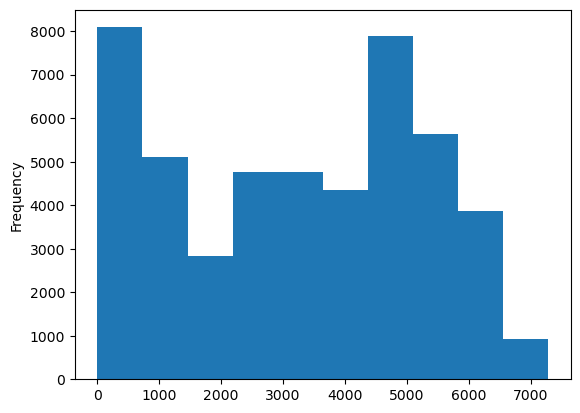

In [7]:
df['traffic_volume'].plot.hist()
plt.show()

In [8]:
df['traffic_volume'].describe()

count    48204.000000
mean      3259.818355
std       1986.860670
min          0.000000
25%       1193.000000
50%       3380.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64

Observations about the distribution of traffic_volume:

The traffic volume ranges from 0 to a maximum of 7,280 cars passing the station per hour.
The average (mean) traffic volume is around 3,260 cars per hour.
About 25% of the time, the traffic volume is quite low, with 1,193 cars or fewer passing each hour. This likely reflects nighttime or low traffic conditions.
However, about 25% of the time, the traffic volume is significantly higher, with 4,933 cars or more per hour.
The histogram typically shows a concentration of values around the middle ranges with tails on both ends indicating variability in traffic volumes.
Regarding whether daytime and nighttime influence traffic volume:

Yes, daytime and nighttime seem to influence traffic volume quite a bit. The lower traffic volumes are likely associated with nighttime (when fewer cars are on the road), while higher traffic volumes occur more often during daytime hours. This is a natural pattern due to commuting patterns, work hours, and general daily activity. It's a reasonable direction to investigate more closely by comparing daytime and nighttime traffic volumes for further insights.

In [9]:
df['date_time'] = pd.to_datetime(df['date_time'], dayfirst=True)

In [10]:
#Isolate the daytime data
day = df[(df['date_time'].dt.hour >= 7) & (df['date_time'].dt.hour < 19)]
#Isolate the nighttime data
night = df[(df['date_time'].dt.hour >= 19) | (df['date_time'].dt.hour < 7)]

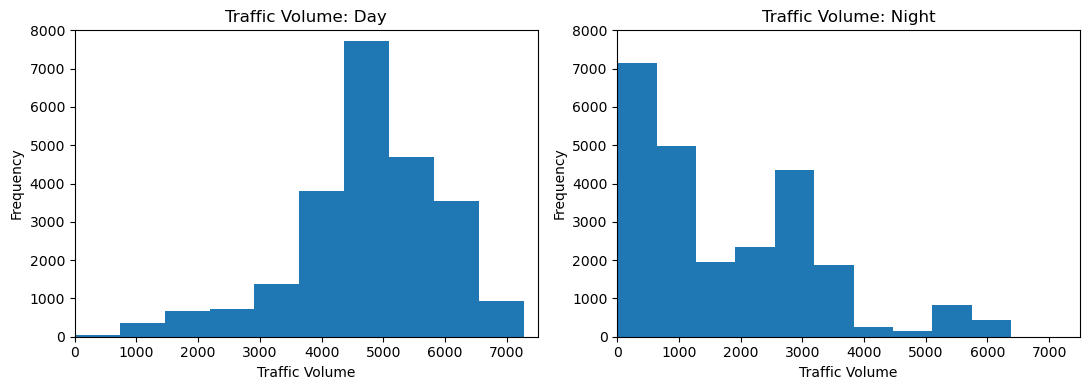

In [11]:
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.hist(day['traffic_volume'])
plt.title('Traffic Volume: Day')
plt.xlabel('Traffic Volume')
plt.ylabel('Frequency')
plt.xlim(0, 7500)
plt.ylim(0, 8000)

plt.subplot(1, 2, 2)
plt.hist(night['traffic_volume'])
plt.title('Traffic Volume: Night')
plt.xlabel('Traffic Volume')
plt.ylabel('Frequency')
plt.xlim(0, 7500)
plt.ylim(0, 8000)

plt.tight_layout()
plt.show()


In [12]:
day['traffic_volume'].describe()

count    23877.000000
mean      4762.047452
std       1174.546482
min          0.000000
25%       4252.000000
50%       4820.000000
75%       5559.000000
max       7280.000000
Name: traffic_volume, dtype: float64

In [13]:
night['traffic_volume'].describe()

count    24327.000000
mean      1785.377441
std       1441.951197
min          0.000000
25%        530.000000
50%       1287.000000
75%       2819.000000
max       6386.000000
Name: traffic_volume, dtype: float64

1. The daytime traffic histogram is actually left-skewed (not perfectly normal). This means most traffic volumes tend to be high during the day, which is consistent with the higher average traffic volume you observed (~4762). The distribution is concentrated on higher traffic values, indicating heavy traffic is more common during the day.
2. The nighttime traffic histogram is right-skewed (right-tailed), meaning most traffic volumes are low, often between 0 and 3000 cars, reflecting generally lighter traffic at night.
3. Since our goal is to find indicators of heavy traffic, and the traffic at night is relatively lighter at night compare to day time traffic; we should not be using the nighttime data.

We determined that the traffic at night is generally light. Our goal is to find indicators of heavy traffic, so we are going to only focus on the daytime data moving forward.

One of the possible indicators of heavy traffic is time. There might be more people on the road in a certain month, on a certain day, or at a certain time of the day.

We're going to look at a few line plots showing how the traffic volume changed according to the following parameters:

1. Month
2. Day of the week
3. Time of day

In [14]:
day['month'] = day['date_time'].dt.month
by_month = day.groupby('month').mean(numeric_only=True)
by_month['traffic_volume']

C:\Users\nites\AppData\Local\Temp\ipykernel_10836\1477755823.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day['month'] = day['date_time'].dt.month


month
1     4495.613727
2     4711.198394
3     4889.409560
4     4906.894305
5     4911.121609
6     4898.019566
7     4595.035744
8     4928.302035
9     4870.783145
10    4921.234922
11    4704.094319
12    4374.834566
Name: traffic_volume, dtype: float64

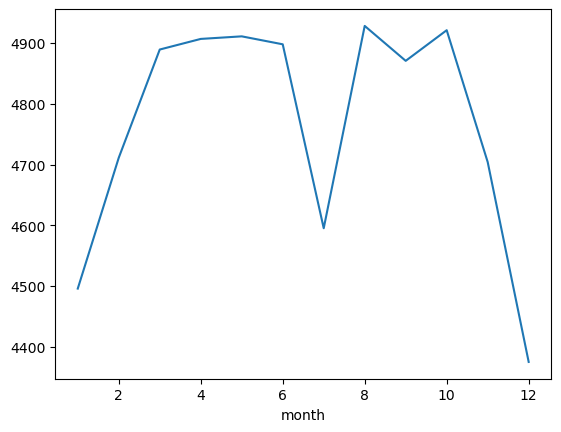

In [15]:
by_month['traffic_volume'].plot.line()
plt.show()

The line plot showing average traffic volume by month generally reveals that traffic is heavier during warm months (March to October) and lighter during cold months (November to February). However, one interesting exception is July, where the traffic volume dips notably compared to the other warm months.

This suggests that something specific about July causes a decrease in traffic volume, which could be related to factors like holidays or special events. In fact, looking at the data year by year for July might reveal more context—such as road construction in 2016 leading to lower traffic that year.

In [16]:
day['dayofweek'] = day['date_time'].dt.dayofweek
by_dayofweek = day.groupby('dayofweek').mean(numeric_only=True)
by_dayofweek['traffic_volume']  # 0 is Monday, 6 is Sunday

C:\Users\nites\AppData\Local\Temp\ipykernel_10836\584712418.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day['dayofweek'] = day['date_time'].dt.dayofweek


dayofweek
0    4893.551286
1    5189.004782
2    5284.454282
3    5311.303730
4    5291.600829
5    3927.249558
6    3436.541789
Name: traffic_volume, dtype: float64

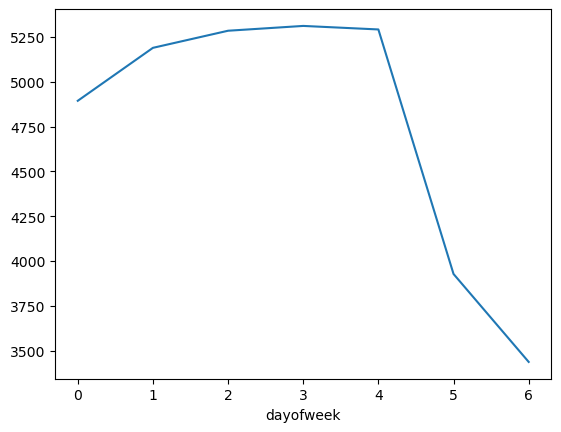

In [17]:
by_dayofweek['traffic_volume'].plot.line()
plt.show()

The line plot showing average traffic volume by day of week, generally reveals that traffic is heavier during monday to friday (business days) and declining to lighter during the weekend. 
This infers that people tend to commute more for work than any other weekend activity.

Since the business day and weekend showed two different patterns, we will try to split the data into two category (mon-fri and sat-sun) and analyse the traffic pattern for the time of day.

In [18]:
day['hour'] = day['date_time'].dt.hour
business_days = day.copy()[day['dayofweek'] <= 4] # 4 == Friday
weekend = day.copy()[day['dayofweek'] >= 5] # 5 == Saturday
by_hour_business = business_days.groupby('hour').mean(numeric_only=True)
by_hour_weekend = weekend.groupby('hour').mean(numeric_only=True)

print(by_hour_business['traffic_volume'])
print(by_hour_weekend['traffic_volume'])

hour
7     6030.413559
8     5503.497970
9     4895.269257
10    4378.419118
11    4633.419470
12    4855.382143
13    4859.180473
14    5152.995778
15    5592.897768
16    6189.473647
17    5784.827133
18    4434.209431
Name: traffic_volume, dtype: float64
hour
7     1589.365894
8     2338.578073
9     3111.623917
10    3686.632302
11    4044.154955
12    4372.482883
13    4362.296564
14    4358.543796
15    4342.456881
16    4339.693805
17    4151.919929
18    3811.792279
Name: traffic_volume, dtype: float64


C:\Users\nites\AppData\Local\Temp\ipykernel_10836\1795081692.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day['hour'] = day['date_time'].dt.hour


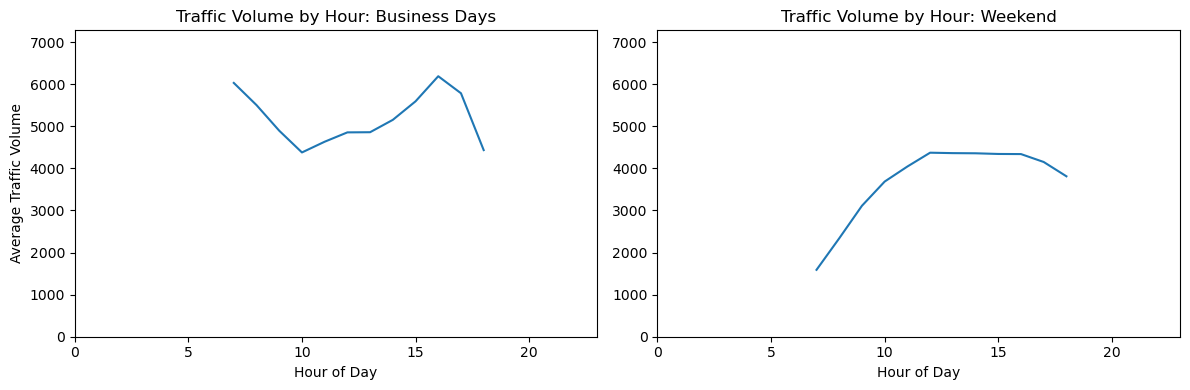

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
by_hour_business['traffic_volume'].plot.line()
plt.title('Traffic Volume by Hour: Business Days')
plt.xlim(0, 23)
plt.ylim(day['traffic_volume'].min(), day['traffic_volume'].max())
plt.xlabel('Hour of Day')
plt.ylabel('Average Traffic Volume')

plt.subplot(1, 2, 2)
by_hour_weekend['traffic_volume'].plot.line()
plt.title('Traffic Volume by Hour: Weekend')
plt.xlim(0, 23)
plt.ylim(day['traffic_volume'].min(), day['traffic_volume'].max())
plt.xlabel('Hour of Day')

plt.tight_layout()
plt.show()

1. From the Business Days chart, traffic volume is generally heavy between 7 AM and 6 PM, with values ranging roughly between 4,000 and 6,000 cars. The rush hours are clearly visible in the morning around 7 to 10 AM and again in the late afternoon, approximately around 4 PM, where the volume peaks above 6,000 cars.
2. From the Weekend chart, while traffic volume also spans from around 7 AM to 6 PM, the volumes are significantly lower than on business days, ranging roughly from 1,500 to 4,500 cars. The traffic pattern on weekends is smoother with no distinct rush hours like on business days.

### Summarizing the findings from all the the time indicators

1. Traffic is generally heavier during warm months (March to October) compared to cold months (November to February).
2. Traffic volume is higher on business days (Monday to Friday) than on weekends.
On business days, the busiest rush hours are around 7 AM and 4 PM, likely corresponding to commuting times for work.
3. Traffic volumes during these rush hours on business days can exceed 6,000 cars per hour.
   
These observations suggest that both season and day type (business day vs weekend) significantly influence heavy traffic patterns, with peak congestions occurring at typical commute times on weekdays.

### Correlation of weather columns and traffic volume

In [26]:
numerical_weather_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume']
day[numerical_weather_cols].corr()['traffic_volume']

temp              0.128317
rain_1h           0.003697
snow_1h           0.001265
clouds_all       -0.032932
traffic_volume    1.000000
Name: traffic_volume, dtype: float64

Looking at the correlation values between traffic_volume and the numerical weather columns, temperature (temp) shows the strongest correlation with about +0.13, while rain_1h, snow_1h, and clouds_all show very weak correlations.

Therefore, the weather column with the strongest correlation with traffic_volume is the temperature (temp) column.

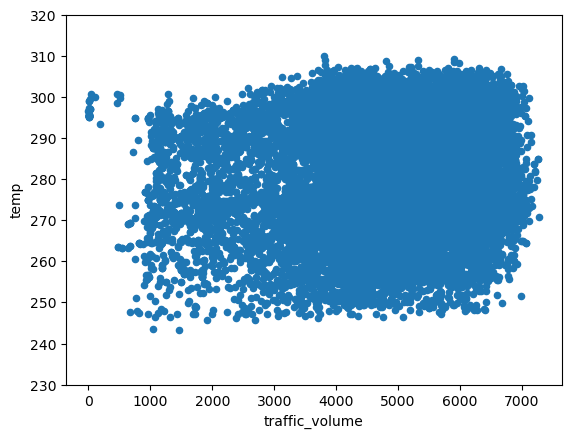

In [29]:
day.plot.scatter(x='traffic_volume', y='temp')
plt.ylim(230, 320)  # Limit y-axis to ignore extreme temperature values
plt.show()


The scatter plot of temperature vs. traffic volume doesn't show a strong pattern to confidently say temperature is a reliable indicator.
However, overall, the numerical weather columns alone don't strongly indicate heavy traffic. Some specific weather conditions might be associated with heavier traffic, but these shouldn't be considered very reliable indicators on their own.

To see if we can find more useful data, we'll look next at the categorical weather-related columns: weather_main and weather_description.

In [30]:
by_weather_main = day.groupby('weather_main').mean(numeric_only=True)
by_weather_description = day.groupby('weather_description').mean(numeric_only=True)

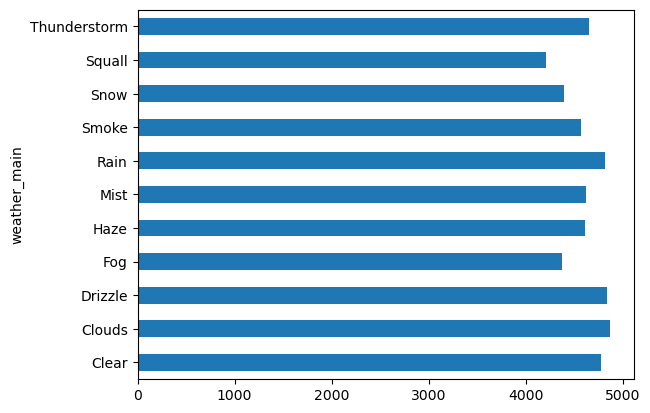

In [35]:
by_weather_main['traffic_volume'].plot.barh()
plt.show()

For weather_main, it's usually difficult to find any traffic volume exceeding 5,000 cars per hour. This suggests that the main weather categories may not strongly indicate heavy traffic.

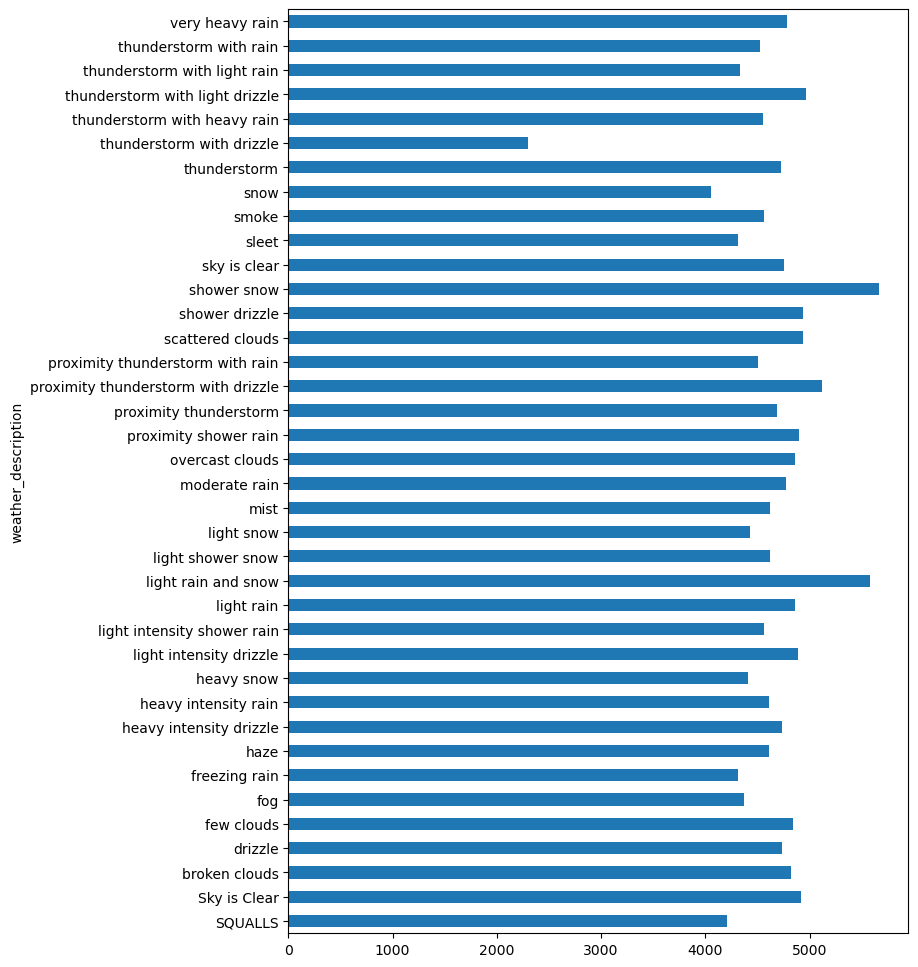

In [37]:
plt.figure(figsize=(8, 12))
by_weather_description['traffic_volume'].plot.barh()
plt.show()

The horizontal bar plot for traffic_volume by weather_description shows that there are indeed some weather types where traffic volume exceeds 5,000 cars.

1. Shower snow
2. Light rain and snow
3. Proximity thunderstorm with drizzle
   
These weather types correspond to poor weather conditions, but not extremely severe. One possible explanation is that during such weather, more people might opt to drive rather than use other means like biking or walking, leading to heavier traffic.

So, these specific weather conditions can be considered as indicators of heavy traffic on I-94.

# Overall Summary for this project

In this project, we explored the I-94 traffic dataset to identify indicators of heavy traffic. We found two main types of indicators:

### Time indicators:

1. Traffic tends to be heavier during warm months (March to October) compared to cold months (November to February).
2. Traffic is generally heavier on business days (Monday to Friday) than on weekends.
3. Rush hours on business days are typically around 7 AM and 4 PM, with traffic volumes exceeding 6,000 cars.


### Weather indicators:

1. Specific weather conditions such as shower snow, light rain and snow, and proximity thunderstorms with drizzle are associated with heavier traffic volumes exceeding 5,000 cars.
2. These weather types likely encourage more people to drive rather than use alternative transportation modes.

    
    Overall, time of day, day of the week, season, and certain weather conditions can serve as useful indicators of heavy traffic on the westbound I-94 highway near the studied station.